In [ ]:
# Trading ML Pipeline — Local (cascade_v3)
## 3-Model: LGBM (entry) → LSTM (confirmation) → Guardian v3 (dynamic exit)
## TP/SL: Hybrid H4 Swing + ATR Fallback (non-ML)
## GPU: AMD RX 6600 — LGBM via OpenCL | LSTM via DirectML
## Workspace: D:\Apps-Dev\Riset_pemodelan
## TRAIN_CUTOFF_DATE = 2025-05-01 — NO TEST DATA IN TRAINING

# Trading ML Pipeline — Local (cascade_v3)
## 3-Model: LGBM (entry) → LSTM (confirmation) → Guardian v3 (dynamic exit)
## GPU: AMD RX 6600 — LGBM OpenCL | LSTM DirectML | Guardian OpenCL
## TRAIN_CUTOFF: 2025-05-01 | Holdout: Mei 2025 – Apr 2026

In [2]:
import os, sys
from pathlib import Path

WORKSPACE = Path(r"D:\Apps-Dev\Riset_pemodelan")
os.chdir(WORKSPACE)
sys.path.insert(0, str(WORKSPACE))
print(f"Workspace : {Path.cwd()}")

import torch
from core.utils import get_device
device = get_device()
print(f"PyTorch   : {torch.__version__}")
print(f"Device    : {device}")
try:
    import torch_directml
    print(f"DirectML  : ✅ {torch_directml.device_name(0)}")
except Exception as e:
    print(f"DirectML  : ❌ {e}")

Workspace : d:\Apps-Dev\Riset_pemodelan
PyTorch   : 2.4.1+cpu
Device    : privateuseone:0
DirectML  : ✅ AMD Radeon RX 6600 


In [3]:
import os
os.chdir(r"D:\Apps-Dev\Riset_pemodelan")
print(f"CWD: {os.getcwd()}")

CWD: d:\Apps-Dev\Riset_pemodelan


In [ ]:
# Install dependencies — jalankan sekali saja
!pip install -q lightgbm scikit-learn shap pyarrow joblib pandas numpy matplotlib seaborn ipywidgets
# PyTorch 2.4.1 + DirectML untuk AMD GPU (Windows)
!pip install -q "torch==2.4.1" --index-url https://download.pytorch.org/whl/cpu
!pip install -q torch-directml
print("✅ Dependencies installed")

In [4]:
import torch
print(f"PyTorch : {torch.__version__}")

if torch.cuda.is_available():
    print(f"✅ CUDA     : {torch.cuda.get_device_name(0)}")
    print(f"   VRAM     : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("   CUDA     : tidak tersedia")

try:
    import torch_directml
    dml = torch_directml.device()
    print(f"✅ DirectML : {dml}")
    print(f"   GPU name : {torch_directml.device_name(0)}")
except Exception as e:
    print(f"⚠️  DirectML : {e}")

from core.utils import get_device
print(f"\n→ Active device : {get_device()}")

PyTorch : 2.4.1+cpu
   CUDA     : tidak tersedia
✅ DirectML : privateuseone:0
   GPU name : AMD Radeon RX 6600 

→ Active device : privateuseone:0


In [ ]:
import os
os.chdir(r"D:\Apps-Dev\Riset_pemodelan")
from config import TRAINING_COINS, ALL_COINS, MODEL_DIR, LGBM_PARAMS

print(f"Training coins : {TRAINING_COINS}")
print(f"Total coins    : {len(ALL_COINS)}")
print(f"Model dir      : {MODEL_DIR}")
print(f"LGBM device    : {LGBM_PARAMS.get('device_type', 'cpu')}")
MODEL_DIR.mkdir(parents=True, exist_ok=True)
print("✅ Config loaded")

In [ ]:
# ═══════════════════════════════════════════════════════════════════
# RESET — Hapus model untuk training ulang
# Uncomment bagian yang diinginkan, lalu jalankan cell ini
# ═══════════════════════════════════════════════════════════════════
from pathlib import Path
from config import MODEL_DIR

def _reset(files: list[str]):
    deleted = []
    for f in files:
        p = MODEL_DIR / f
        if p.exists():
            p.unlink()
            deleted.append(f)
    print(f"Deleted ({len(deleted)}): {deleted}" if deleted else "No files to delete")

# ── Reset SEMUA model (full retrain dari 05) ─────────────────────
_reset([
    "lgbm_baseline.pkl", "feature_cols_v2.json", "cv_results.json",
    "lstm_best.pt", "lstm_scaler.pkl", "lstm_cv_results.json",
    "guardian_best.pkl", "guardian_scaler.pkl", "guardian_feature_cols.json",
    "inference_config.json", "model_registry.json",
])

# ── Reset LGBM saja ──────────────────────────────────────────────
# _reset(["lgbm_baseline.pkl", "feature_cols_v2.json", "cv_results.json"])

# ── Reset LSTM saja ──────────────────────────────────────────────
# _reset(["lstm_best.pt", "lstm_scaler.pkl", "lstm_cv_results.json"])

# ── Reset Guardian saja ──────────────────────────────────────────
# _reset(["guardian_best.pkl", "guardian_scaler.pkl", "guardian_feature_cols.json"])

In [6]:
# Fetch semua 18 koin (training + new)
# Estimasi waktu: 30-60 menit pertama kali
# Gunakan --reset hanya jika ingin re-fetch dari awal
!python pipeline/01_fetch.py --all

2026-05-09 11:08:36 | INFO     | 01_fetch | ============================================================
2026-05-09 11:08:36 | INFO     | 01_fetch |   FETCH DATA: ALL COINS (2020-01-01 → 2026-04-01)
2026-05-09 11:08:36 | INFO     | 01_fetch |   Koin    : ['SOLUSDT', 'ETHUSDT', 'BNBUSDT', 'XRPUSDT', 'DOGEUSDT', 'TONUSDT', 'ADAUSDT', 'TRXUSDT', '1000SHIBUSDT', 'AVAXUSDT', 'LINKUSDT', 'DOTUSDT', 'SUIUSDT', 'POLUSDT', 'NEARUSDT', '1000PEPEUSDT', 'TAOUSDT', 'ARBUSDT', 'XAUTUSDT', 'HBARUSDT', 'ONDOUSDT']
2026-05-09 11:08:36 | INFO     | 01_fetch |   Macro   : 2020-01-01 → 2026-04-01
2026-05-09 11:08:36 | INFO     | 01_fetch | ============================================================
2026-05-09 11:08:36 | INFO     | 01_fetch | Progress loaded: 58 keys selesai.
2026-05-09 11:08:42 | INFO     | binance_client | ✅ Connection OK via futures
2026-05-09 11:08:42 | INFO     | 01_fetch | Koneksi Binance OK.
2026-05-09 11:08:42 | INFO     | 01_fetch | 
--- FETCH MACRO DATA ---
2026-05-09 11:08:42 |

In [1]:
# Verifikasi data hasil fetch
import os
from pathlib import Path

raw_dir = Path("data/raw/klines")
if raw_dir.exists():
    coins = [d.name for d in raw_dir.iterdir() if d.is_dir()]
    print(f"Koin tersedia: {len(coins)} — {coins[:5]}...")
else:
    print("data/raw/klines belum ada — jalankan cell fetch terlebih dahulu")

Koin tersedia: 21 — ['1000PEPEUSDT', '1000SHIBUSDT', 'ADAUSDT', 'ARBUSDT', 'AVAXUSDT']...


In [2]:
# Verifikasi data hasil fetch — semua koin
import os
from pathlib import Path

raw_dir = Path("data/raw/klines")
files = list(os.walk(raw_dir))
for root, dirs, fs in files[:8]:
    if fs:
        print(f"{Path(root).name}: {len(fs)} files")
print(f"... total {sum(len(fs) for _, _, fs in files if fs)} files")

1000PEPEUSDT: 3 files
1000SHIBUSDT: 3 files
ADAUSDT: 3 files
ARBUSDT: 3 files
AVAXUSDT: 3 files
BNBUSDT: 3 files
DOGEUSDT: 3 files
... total 63 files


In [9]:
!python pipeline/02_clean.py --all

2026-05-09 11:11:14 | INFO     | 02_clean | [SOLUSDT] Starting cleaning...
2026-05-09 11:11:16 | INFO     | 02_clean | [SOLUSDT] 1h: 32,410 rows, 36 gaps
2026-05-09 11:11:16 | INFO     | 02_clean | [SOLUSDT] 4h: 8,353 rows, 8 gaps
2026-05-09 11:11:16 | INFO     | 02_clean | [SOLUSDT] 1d: 1,782 rows, 1 gaps
2026-05-09 11:11:16 | INFO     | 02_clean | [SOLUSDT] Saved → d:\Apps-Dev\Riset_pemodelan\data\processed\SOLUSDT_clean.parquet (32,410 rows × 29 cols)
2026-05-09 11:11:16 | INFO     | 02_clean | [ETHUSDT] Starting cleaning...
2026-05-09 11:11:17 | INFO     | 02_clean | [ETHUSDT] 1h: 36,768 rows, 43 gaps
2026-05-09 11:11:17 | INFO     | 02_clean | [ETHUSDT] 4h: 9,192 rows, 10 gaps
2026-05-09 11:11:17 | INFO     | 02_clean | [ETHUSDT] 1d: 1,782 rows, 1 gaps
2026-05-09 11:11:18 | INFO     | 02_clean | [ETHUSDT] Saved → d:\Apps-Dev\Riset_pemodelan\data\processed\ETHUSDT_clean.parquet (36,768 rows × 29 cols)
2026-05-09 11:11:18 | INFO     | 02_clean | [BNBUSDT] Starting cleaning...
2026-0

In [ ]:
# Fase 03 [OPSIONAL]: Grid Search Parameter Swing Labeling
# Mencari kombinasi optimal: SWING_H4_LOOKBACK, SWING_LABEL_MIN_RR, SWING_LABEL_MIN_TP, SWING_LABEL_MAX_SL
# Output: rekomendasi parameter — update config.py sebelum lanjut ke engineer
# Estimasi waktu: 10-20 menit
#
# Skip cell ini jika parameter swing sudah dikonfigurasi.
!python pipeline/03_analyze_swing.py --all --top 15

In [3]:
# Verifikasi fitur baru (smart money v4) tersedia di feature engineering
!grep -n "calc_ofi_features\|calc_vwdp\|calc_vsa\|calc_trend_acceleration\|calc_volume_price_confirm\|calc_dist_from_recent_high" core/features.py

'grep' is not recognized as an internal or external command,
operable program or batch file.


In [5]:
# Fase 04: Feature Engineering + Swing Labeling
# Output: data/labeled/{SYMBOL}_features_v3.parquet
# Estimasi waktu: 15-30 menit
!python pipeline/04_engineer.py --all

2026-05-09 11:27:39 | INFO     | 04_engineer | [SOLUSDT] Starting feature engineering v3...
2026-05-09 11:28:30 | INFO     | features | [SOLUSDT] Swing-Based labeling v3 (max_hold=24h, min_rr=1.2, min_tp=1.2×ATR, max_sl=3.0×ATR)...
2026-05-09 11:28:31 | INFO     | features | Structural filter: 272 LONG → FLAT, 285 SHORT → FLAT
2026-05-09 11:28:31 | INFO     | features | [SOLUSDT] Label distribution v3: LONG=2657 (8.2%), SHORT=2845 (8.8%), FLAT=26908 (83.0%)
2026-05-09 11:28:31 | INFO     | features | [SOLUSDT] Features v3: 32,410 rows × 104 cols | NaN: 1.0%
2026-05-09 11:28:31 | INFO     | 04_engineer | [SOLUSDT] Saved 32397 rows to SOLUSDT_features_v3.parquet
2026-05-09 11:28:31 | INFO     | 04_engineer | [ETHUSDT] Starting feature engineering v3...
2026-05-09 11:29:22 | INFO     | features | [ETHUSDT] Swing-Based labeling v3 (max_hold=24h, min_rr=1.2, min_tp=1.2×ATR, max_sl=3.0×ATR)...
2026-05-09 11:29:23 | INFO     | features | Structural filter: 352 LONG → FLAT, 276 SHORT → FLAT
20

In [6]:
!python pipeline/analyze_min_hold.py --save-plot

[INFO] LABEL_DIR      = d:\Apps-Dev\Riset_pemodelan\data\labeled
[INFO] MAX_HOLDING_BARS = 24
  Loading 1000PEPEUSDT...
    17,457 rows | cols: ['open', 'high', 'low', 'close', 'volume', 'volume_delta', 'cvd', 'buy_volume']...
    → 2,688 entries LONG/SHORT | median=3h | p10=1h
  Loading 1000SHIBUSDT...
    28,864 rows | cols: ['open', 'high', 'low', 'close', 'volume', 'volume_delta', 'cvd', 'buy_volume']...
    → 4,843 entries LONG/SHORT | median=3h | p10=1h
  Loading ADAUSDT...
    36,755 rows | cols: ['open', 'high', 'low', 'close', 'volume', 'volume_delta', 'cvd', 'buy_volume']...
    → 6,323 entries LONG/SHORT | median=3h | p10=2h
  Loading ARBUSDT...
    17,991 rows | cols: ['open', 'high', 'low', 'close', 'volume', 'volume_delta', 'cvd', 'buy_volume']...
    → 3,183 entries LONG/SHORT | median=3h | p10=1h
  Loading AVAXUSDT...
    32,755 rows | cols: ['open', 'high', 'low', 'close', 'volume', 'volume_delta', 'cvd', 'buy_volume']...
    → 5,416 entries LONG/SHORT | median=3h | p1

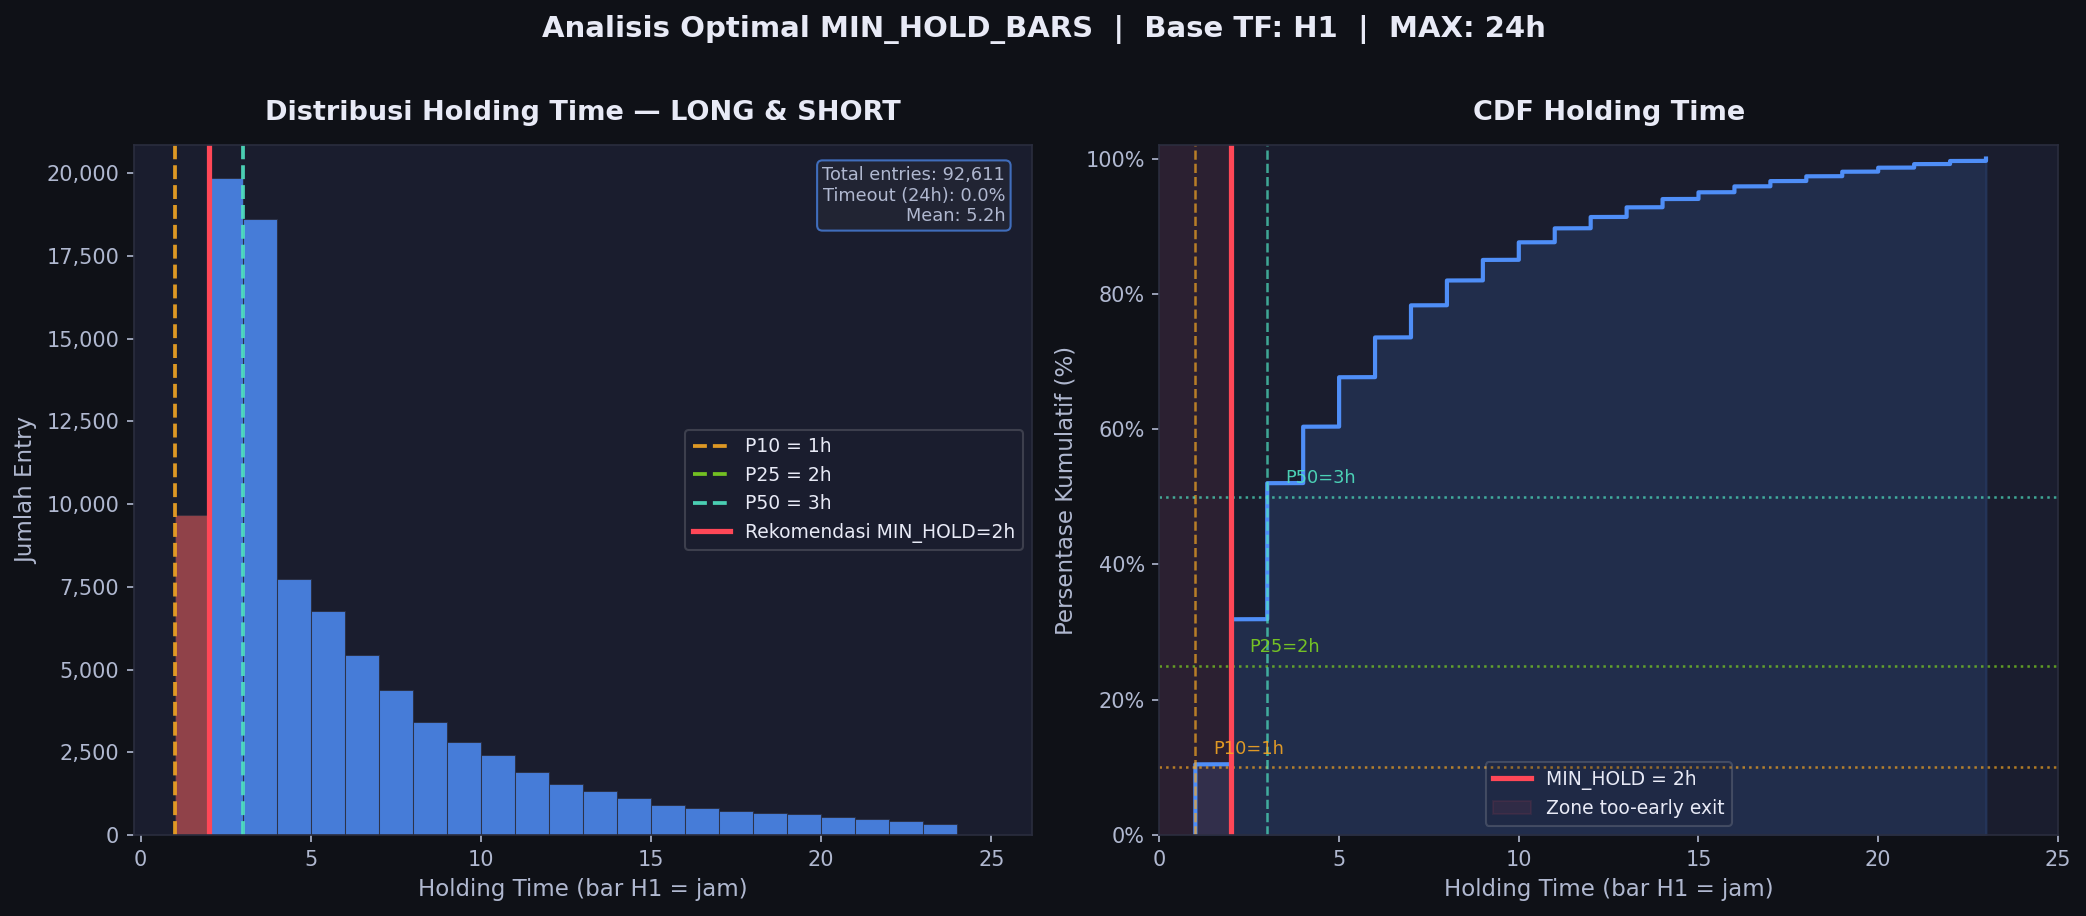

In [7]:
from IPython.display import Image, display
from pathlib import Path

# Tampilkan hasil analisis min_hold
img_path = Path("reports/min_hold_analysis.png")
if img_path.exists():
    display(Image(filename=str(img_path)))
else:
    print("min_hold_analysis.png belum ada — jalankan cell analyze_min_hold terlebih dahulu")

In [ ]:
# NOTE: Arsitektur cascade_v3 — 3-Model: LGBM → LSTM → Guardian v3
#
# Training otomatis terpotong di TRAIN_CUTOFF_DATE (2025-05-01).
# Holdout test pakai data setelah cutoff — genuine temporal OOS.
#
# Yang sudah DIHAPUS dari arsitektur:
#   - H4 LGBM (AUC 0.55, near-random)
#   - TP/SL Regressor (SL R²=0.05)
#   - LSTM FLAT review (WR 39%, menurunkan cascade WR 78%→57%)
#
# Lanjut ke LGBM training.

In [ ]:
# Fase 05: Latih LGBM (Entry Signal Generator — Primary Model)
# 3-class: SHORT / FLAT / LONG
# Cost-sensitive class weights: SHORT=3x, FLAT=1.5x, LONG=3x
# Estimasi waktu: 15-30 menit
!python pipeline/05_train_lgbm.py --all

2026-05-09 11:49:23 | INFO     | 05_train_lgbm | Run ID: run_20260509_114923 | Output: d:\Apps-Dev\Riset_pemodelan\models\runs\run_20260509_114923
2026-05-09 11:49:23 | INFO     | 05_train_lgbm | Loaded SOLUSDT: 32,397 rows
2026-05-09 11:49:23 | INFO     | 05_train_lgbm | Loaded ETHUSDT: 36,755 rows
2026-05-09 11:49:23 | INFO     | 05_train_lgbm | Loaded BNBUSDT: 36,755 rows
2026-05-09 11:49:23 | INFO     | 05_train_lgbm | Loaded XRPUSDT: 36,755 rows
2026-05-09 11:49:23 | INFO     | 05_train_lgbm | Loaded DOGEUSDT: 36,755 rows
2026-05-09 11:49:23 | INFO     | 05_train_lgbm | Loaded TONUSDT: 9,901 rows
2026-05-09 11:49:23 | INFO     | 05_train_lgbm | Loaded ADAUSDT: 36,755 rows
2026-05-09 11:49:23 | INFO     | 05_train_lgbm | Loaded TRXUSDT: 36,755 rows
2026-05-09 11:49:23 | INFO     | 05_train_lgbm | Loaded 1000SHIBUSDT: 28,864 rows
2026-05-09 11:49:23 | INFO     | 05_train_lgbm | Loaded AVAXUSDT: 32,755 rows
2026-05-09 11:49:24 | INFO     | 05_train_lgbm | Loaded LINKUSDT: 36,755 rows

In [10]:
# Benchmark LGBM — evaluasi hasil training
import json
from config import MODEL_DIR

cv_path = MODEL_DIR / "cv_results.json"
if not cv_path.exists():
    print("❌ cv_results.json belum ada — jalankan 05_train_lgbm.py dulu")
else:
    with open(cv_path) as f:
        cv = json.load(f)
    f1 = cv["mean_f1_macro"]
    grade = ("✅ SANGAT BAGUS" if f1 >= 0.55 else
             "✅ BAGUS"        if f1 >= 0.50 else
             "⚠️  ACCEPTABLE"  if f1 >= 0.45 else
             "❌ PERLU RE-TUNING")

    print("=" * 58)
    print("  LGBM BENCHMARK")
    print("=" * 58)
    print(f"  Mean F1-macro : {f1:.4f}  →  {grade}")
    print(f"  Best F1-macro : {cv['best_f1_macro']:.4f}  (fold {cv['best_fold']})")
    print(f"  Std  F1-macro : ±{cv['std_f1_macro']:.4f}")
    print(f"\n  {'Fold':>4}  {'F1-mac':>7}  {'LONG':>7}  {'SHORT':>7}  {'FLAT':>7}")
    print("  " + "-" * 40)
    for m in cv["folds"]:
        print(f"  {m['fold']:>4}  {m['f1_macro']:>7.4f}  "
              f"{m['f1_LONG']:>7.4f}  {m['f1_SHORT']:>7.4f}  {m['f1_FLAT']:>7.4f}")
    print("\n  Panduan: ≥0.55 Sangat Bagus | ≥0.50 Bagus | ≥0.45 Acceptable | <0.45 Re-tuning")
    print("  Tips re-tuning: turunkan LGBM_THRESHOLD_LONG/SHORT, naikkan n_estimators, atau tambah fitur")

  LGBM BENCHMARK
  Mean F1-macro : 0.7194  →  ✅ SANGAT BAGUS
  Best F1-macro : 0.7550  (fold 7)
  Std  F1-macro : ±0.0293

  Fold   F1-mac     LONG    SHORT     FLAT
  ----------------------------------------
     1   0.7138   0.6316   0.5918   0.9180
     2   0.7326   0.6300   0.6293   0.9385
     3   0.6647   0.5301   0.5618   0.9022
     4   0.6811   0.5446   0.5852   0.9136
     5   0.7288   0.6384   0.6297   0.9184
     6   0.7429   0.6540   0.6557   0.9189
     7   0.7550   0.6660   0.6597   0.9393
     8   0.7360   0.6350   0.6359   0.9371

  Panduan: ≥0.55 Sangat Bagus | ≥0.50 Bagus | ≥0.45 Acceptable | <0.45 Re-tuning
  Tips re-tuning: turunkan LGBM_THRESHOLD_LONG/SHORT, naikkan n_estimators, atau tambah fitur


In [11]:
# Verifikasi LGBM model sudah terlatih
from pathlib import Path
from config import MODEL_DIR

model_files = ["lgbm_baseline.pkl", "feature_cols_v2.json"]
for f in model_files:
    p = MODEL_DIR / f
    if p.exists():
        print(f"  ✅ {f}  ({p.stat().st_size / 1e6:.1f} MB)")
    else:
        print(f"  ❌ {f} — belum ada, jalankan 05_train_lgbm.py terlebih dahulu")

  ✅ lgbm_baseline.pkl  (10.7 MB)
  ✅ feature_cols_v2.json  (0.0 MB)


In [ ]:
# NOTE: Arsitektur cascade_v3 — 3-Model: LGBM → LSTM → Guardian v3
#
# ENTRY (2-model cascade):
#   LGBM predict_proba() → confidence >= 0.62?
#     → YES: LSTM soft adjustment (tiered: agree +0.05, neutral -0.05, opposite -0.04×mul)
#     → NO:  FLAT (no trade)
#   Adjusted confidence >= 0.62?
#     → YES: ENTRY SIGNAL (LONG/SHORT)
#     → NO:  FLAT
#
# TP/SL (non-ML, 2-tier hybrid):
#   1. Swing H4 structural levels (prioritas)
#   2. ATR fallback: TP=2.0×ATR, SL=1.5×ATR (jika swing NaN)
#   Hybrid mode: TP=max(swing, ATR), SL=min(swing, ATR)
#
# EXIT (Guardian v3 — 3rd model, per-bar dynamic):
#   Setelah entry + min_hold 3 bar + price moved 1×ATR:
#     Guardian predict → 0=HOLD, 1=PARTIAL_EXIT(50%), 2=FULL_EXIT
#   Guardian v3: 103 static feat + 7 dynamic feat, multiclass LGBM
#   TRAILING_STOP_ENABLED = False (Guardian solo beats trailing)
#
# Logic cascade : pipeline/backtest_utils.py → hierarchical_predict()
# TP/SL + exit : core/evaluator.py → simulate_trades_swing()

print("cascade_v3 aktif — 3 model (LGBM + LSTM + Guardian v3). Lanjut ke Fase 07.")

In [14]:
# Cek GPU sebelum LSTM training
import torch
from core.utils import get_lstm_device
from core.models import TradingLSTM

device = get_lstm_device()
print(f'LSTM device : {device}')

try:
    model = TradingLSTM(n_features=103, hidden_size=128, num_layers=2).to(device)
    x   = torch.randn(16, 16, 103).to(device)
    out = model(x)
    out.sum().backward()
    print('Forward : OK', tuple(out.shape))
    print('Backward: OK')
    del model, x, out
    print('\nGPU siap - lanjut training LSTM')
except Exception as e:
    print(f'GPU test gagal: {e}')
    print('Cek instalasi torch-directml atau jalankan cell-3 dulu')


LSTM device : privateuseone:0
Forward : OK (16, 3)
Backward: OK

GPU siap - lanjut training LSTM


In [ ]:
# Fase 06: Latih LSTM (Confirmation Vote)
# LSTM memberikan soft adjustment terhadap confidence LGBM: agree=boost, opposite=penalty
# Input: sequence 16 bar H1 terakhir
# Estimasi waktu: 30-60 menit (GPU direkomendasikan)
!python -u pipeline/06_train_lstm.py --all     

In [ ]:
import json
from pathlib import Path
from config import MODEL_DIR

registry = {
    "active": "cascade_v3",
    "architecture": "3-Model Cascade (LGBM → LSTM → Guardian v3) + Hybrid Swing/ATR TP/SL",
    "confidence_threshold_entry": 0.62,
    "models": {
        "lgbm": {
            "role": "Entry Signal Generator (3-class: SHORT/FLAT/LONG)",
            "n_features": 103,
            "threshold_long": 0.62,
            "threshold_short": 0.62,
            "class_weights": {"SHORT": 3.0, "FLAT": 1.5, "LONG": 3.0},
        },
        "lstm": {
            "role": "Confirmation Vote (soft adjustment)",
            "seq_len": 16,
            "hidden": 128,
            "layers": 2,
            "adjust_mode": "tiered",
            "agree_boost": 0.05,
            "neutral_pen": 0.05,
            "opposite_pen": 0.04,
        },
        "guardian_v3": {
            "role": "Dynamic Exit (per-bar: HOLD/PARTIAL_EXIT/FULL_EXIT)",
            "features": "103 static + 7 dynamic",
            "classes": "0=HOLD, 1=PARTIAL_EXIT(50%), 2=FULL_EXIT",
            "threshold": 0.60,
            "min_hold_bars": 3,
            "activation_atr": 1.0,
        },
    },
    "tp_sl": {
        "mode": "Hybrid H4 Swing + ATR Fallback (non-ML)",
        "hybrid": True,
        "tp_fallback_atr": 2.0,
        "sl_fallback_atr": 1.5,
        "min_rr": 1.0,
    },
    "removed": [
        "h4_lgbm (AUC 0.55, near-random)",
        "stacked_ensemble (degradasi sinyal)",
        "tp_sl_regressor (SL R²=0.05, all approaches degraded)",
        "lstm_flat_review (WR 39%, killed 78%→57%)",
    ],
}

MODEL_DIR.mkdir(parents=True, exist_ok=True)
with open(MODEL_DIR / "model_registry.json", "w") as f:
    json.dump(registry, f, indent=2)

print(f"model_registry.json updated — cascade_v3")
print(f"  LGBM entry      : ✅ aktif")
print(f"  LSTM confirm    : ✅ aktif")
print(f"  Guardian v3 exit: ✅ aktif")
print(f"  TP/SL           : Hybrid H4 Swing + ATR Fallback (non-ML)")

In [ ]:
# Fase 07.5: Latih Exit Guardian v3 (103 fitur, multiclass)
# Multiclass LGBM: 0=HOLD, 1=PARTIAL_EXIT(50%), 2=FULL_EXIT
# Guardian aktif per-bar setelah entry: dynamic exit menggantikan static TP/SL
# Training HANYA di data sebelum TRAIN_CUTOFF_DATE (2025-05-01)
# Estimasi waktu: 15-25 menit
# PRASYARAT: 05_train_lgbm.py + 06_train_lstm.py sudah selesai
!python pipeline/15_train_guardian.py --all

In [ ]:
# Fase 08: Walk-Forward Backtest (data training, purged CV)
# Guardian v3 active: GUARDIAN_ENABLED=True, TRAILING_STOP_ENABLED=False
# Output: models/runs/{run_id}/backtest_results.json
!python pipeline/08_backtest.py --all

In [27]:
# Fase 09: Hold-Out Backtest (OOS murni — data setelah periode training)
# Fetch data baru → Clean → Engineer → Backtest tanpa retrain
# Default: 2025-05-01 s/d 2026-04-01
# Output: models/runs/holdout_{run_id}/holdout_backtest_results.json
!python pipeline/09_holdout_backtest.py --all


  HOLD-OUT BACKTEST — holdout_20260509_192754
  Periode : 2025-05-01 - 2026-04-01
  Koin    : ['SOLUSDT', 'ETHUSDT', 'BNBUSDT', 'XRPUSDT', 'DOGEUSDT', 'TONUSDT', 'ADAUSDT', 'TRXUSDT', '1000SHIBUSDT', 'AVAXUSDT', 'LINKUSDT', 'DOTUSDT', 'SUIUSDT', 'POLUSDT', 'NEARUSDT', '1000PEPEUSDT', 'TAOUSDT', 'ARBUSDT', 'XAUTUSDT', 'HBARUSDT', 'ONDOUSDT']

2026-05-09 19:27:54 | INFO     | 09_holdout_backtest | === STEP 1: FETCH HOLD-OUT DATA ===
2026-05-09 19:27:55 | INFO     | binance_client | ✅ Connection OK via futures
2026-05-09 19:27:55 | INFO     | 09_holdout_backtest | Binance OK | Periode: 2025-05-01 - 2026-04-01
2026-05-09 19:27:55 | INFO     | fetchers | =======================================================
2026-05-09 19:27:55 | INFO     | fetchers | FETCH MACRO DATA
2026-05-09 19:27:55 | INFO     | fetchers | =======================================================
2026-05-09 19:27:55 | INFO     | fetchers | Fetching Fear & Greed Index dari alternative.me...
2026-05-09 19:27:57 | INFO   

In [ ]:
# Benchmark Backtest — evaluasi performa trading (Guardian v3)
import json
from config import MODEL_DIR

cfg_path = MODEL_DIR / "inference_config.json"
if not cfg_path.exists():
    print("inference_config.json belum ada — jalankan 08_backtest.py dulu")
else:
    with open(cfg_path) as f:
        cfg = json.load(f)
    bs  = cfg.get("backtest_summary", {})
    wr  = bs.get("mean_winrate", 0)
    sh  = bs.get("mean_sharpe", 0)
    pf  = bs.get("mean_profit_factor", 0)
    dd  = bs.get("mean_drawdown_lev5x", 1)
    tpm = bs.get("mean_trade_per_month", 0)
    mcl = bs.get("max_consecutive_loss", 0)

    def grade(v, hi, mid, lo):
        return ("EXCELLENT" if v >= hi else "BAGUS" if v >= mid else
                "ACCEPTABLE" if v >= lo else "RE-TUNING")

    print("=" * 62)
    print("  BACKTEST BENCHMARK  (Walk-Forward, Leverage 5x, Guardian v3)")
    print("=" * 62)
    print(f"  Win Rate         : {wr:.2%}  {grade(wr, 0.85, 0.80, 0.70)}")
    print(f"  Sharpe Ratio     : {sh:.2f}   {grade(sh, 3.0, 2.0, 1.0)}")
    print(f"  Profit Factor    : {pf:.2f}   {grade(pf, 10.0, 5.0, 2.0)}")
    dd_g = "BAGUS" if dd <= 0.30 else ("ACCEPTABLE" if dd <= 0.60 else "RISIKO TINGGI")
    print(f"  Max Drawdown     : {dd:.2%}  {dd_g}")
    print(f"  Trade / Bulan    : {tpm:.1f}")
    print(f"  Max Consec. Loss : {mcl}")
    print(f"\n  Exit Mode        : Guardian v3 (103 feat, multiclass)")
    print(f"  TP/SL            : Hybrid H4 Swing + ATR Fallback")

    cv = cfg.get("coins_validated", {})
    print(f"\n  Recommended      : {cv.get('recommended', []) or '—'}")
    print(f"  Acceptable       : {cv.get('acceptable', []) or '—'}")
    print(f"  Caution          : {len(cv.get('caution', []))} koin")
    print("\n  Guardian v3 target: WR > 90%, DD < 50%, PF > 15")

In [ ]:
# Fase 10: Visualisasi Backtest + Swing Verification
# Output: reports/training/{SYMBOL}_backtest_visual.png
#         reports/training/{SYMBOL}_swing_verify.png (dengan --verify-swing)
!python pipeline/10_visualize.py --all --verify-swing

# Untuk data hold-out (OOS):
# !python pipeline/10_visualize.py --all --holdout --verify-swing